<a href="https://colab.research.google.com/github/joysujeeth1761/facial_recognition/blob/main/Face_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deepface retina-face
!pip install opencv-python
!pip install matplotlib
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.5 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle

from deepface import DeepFace
from scipy.spatial.distance import cosine

26-05-20 09:51:19 - Directory /root/.deepface has been created
26-05-20 09:51:19 - Directory /root/.deepface/weights has been created


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vasukipatel/face-recognition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-recognition-dataset' dataset.
Path to dataset files: /kaggle/input/face-recognition-dataset


In [ ]:
import os

print(os.listdir(path))

['Faces', 'Original Images', 'Dataset.csv']


In [ ]:
for root, dirs, files in os.walk(path):

    print(root)

    print("Folders:", dirs[:5])

    print("Files:", files[:5])

    print("-"*50)

    break

/kaggle/input/face-recognition-dataset
Folders: ['Faces', 'Original Images']
Files: ['Dataset.csv']
--------------------------------------------------


In [ ]:
dataset_path = os.path.join(
    path,
    "Original Images",
    "Original Images"
)

print(os.listdir(dataset_path)[:5])

['Alia Bhatt', 'Charlize Theron', 'Zac Efron', 'Billie Eilish', 'Jessica Alba']


In [ ]:
import os

image_extensions = ['.jpg', '.jpeg', '.png']

first_image = None

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith(tuple(image_extensions)):

            first_image = os.path.join(root, file)

            break

    if first_image:
        break

print(first_image)

/kaggle/input/face-recognition-dataset/Original Images/Original Images/Alia Bhatt/Alia Bhatt_4.jpg


Shape: (960, 640, 3)


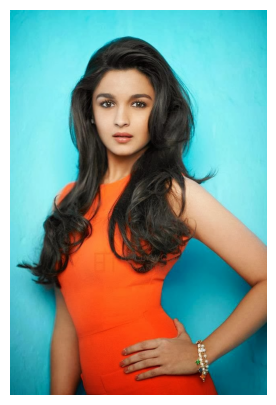

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(first_image)

print("Shape:", img.shape)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))

plt.imshow(img_rgb)

plt.axis('off')

plt.show()

In [ ]:
people = os.listdir(dataset_path)[:3]

In [ ]:
from deepface import DeepFace
import pickle
import os

database = {}

# Use only first 3 people initially
people = os.listdir(dataset_path)[:3]

for person in people:

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    embeddings = []

    print(f"\nProcessing person: {person}")

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        try:

            embedding = DeepFace.represent(
                img_path=img_path,
                model_name='ArcFace',
                detector_backend='retinaface',
                enforce_detection=True
            )

            embeddings.append(
                embedding[0]['embedding']
            )

            print(f"Processed: {img_name}")

        except Exception as e:

            print(f"Failed: {img_name}")

    database[person] = embeddings

# Save database
with open('/content/face_db.pkl', 'wb') as f:

    pickle.dump(database, f)

print("\nDatabase created successfully")


Processing person: Alia Bhatt
26-05-20 05:36:46 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:01<00:00, 108MB/s]


26-05-20 05:36:53 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 122MB/s]


Processed: Alia Bhatt_4.jpg
Processed: Alia Bhatt_33.jpg
Processed: Alia Bhatt_17.jpg
Processed: Alia Bhatt_45.jpg
Processed: Alia Bhatt_51.jpg
Processed: Alia Bhatt_34.jpg
Processed: Alia Bhatt_65.jpg
Processed: Alia Bhatt_39.jpg
Processed: Alia Bhatt_29.jpg
Processed: Alia Bhatt_64.jpg
Processed: Alia Bhatt_52.jpg
Processed: Alia Bhatt_42.jpg
Processed: Alia Bhatt_48.jpg
Processed: Alia Bhatt_15.jpg
Processed: Alia Bhatt_36.jpg
Processed: Alia Bhatt_53.jpg
Processed: Alia Bhatt_14.jpg
Processed: Alia Bhatt_31.jpg
Processed: Alia Bhatt_68.jpg
Processed: Alia Bhatt_11.jpg
Processed: Alia Bhatt_12.jpg
Processed: Alia Bhatt_26.jpg
Processed: Alia Bhatt_69.jpg
Processed: Alia Bhatt_2.jpg
Processed: Alia Bhatt_74.jpg
Processed: Alia Bhatt_13.jpg
Processed: Alia Bhatt_70.jpg
Processed: Alia Bhatt_72.jpg
Processed: Alia Bhatt_10.jpg
Processed: Alia Bhatt_9.jpg
Processed: Alia Bhatt_7.jpg
Processed: Alia Bhatt_46.jpg
Processed: Alia Bhatt_40.jpg
Processed: Alia Bhatt_22.jpg
Processed: Alia Bh

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving PHOTO-2026-05-20-15-17-13.jpg to PHOTO-2026-05-20-15-17-13 (2).jpg


In [ ]:
dataset_path = os.path.join(
    path,
    "Original Images",
    "Original Images"
)

In [ ]:
from deepface import DeepFace
import pickle
import os

database = {}

people = os.listdir(dataset_path)[:3]

for person in people:

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    embeddings = []

    print(f"\nProcessing person: {person}")

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        try:

            embedding = DeepFace.represent(
                img_path=img_path,
                model_name='ArcFace',
                detector_backend='retinaface',
                enforce_detection=True
            )

            embeddings.append(
                embedding[0]['embedding']
            )

            print(f"Processed: {img_name}")

        except Exception as e:

            print(f"Failed: {img_name}")

    database[person] = embeddings

# Save database
with open('/content/face_db.pkl', 'wb') as f:

    pickle.dump(database, f)

print("\nDatabase created successfully")


Processing person: Alia Bhatt


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5


26-05-20 09:56:12 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


100%|██████████| 137M/137M [00:00<00:00, 468MB/s] 
Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5


26-05-20 09:56:15 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


100%|██████████| 119M/119M [00:00<00:00, 433MB/s] 


Processed: Alia Bhatt_4.jpg
Processed: Alia Bhatt_33.jpg
Processed: Alia Bhatt_17.jpg
Processed: Alia Bhatt_45.jpg
Processed: Alia Bhatt_51.jpg
Processed: Alia Bhatt_34.jpg
Processed: Alia Bhatt_65.jpg
Processed: Alia Bhatt_39.jpg
Processed: Alia Bhatt_29.jpg
Processed: Alia Bhatt_64.jpg
Processed: Alia Bhatt_52.jpg
Processed: Alia Bhatt_42.jpg
Processed: Alia Bhatt_48.jpg
Processed: Alia Bhatt_15.jpg
Processed: Alia Bhatt_36.jpg
Processed: Alia Bhatt_53.jpg
Processed: Alia Bhatt_14.jpg
Processed: Alia Bhatt_31.jpg
Processed: Alia Bhatt_68.jpg
Processed: Alia Bhatt_11.jpg
Processed: Alia Bhatt_12.jpg
Processed: Alia Bhatt_26.jpg
Processed: Alia Bhatt_69.jpg
Processed: Alia Bhatt_2.jpg
Processed: Alia Bhatt_74.jpg
Processed: Alia Bhatt_13.jpg
Processed: Alia Bhatt_70.jpg
Processed: Alia Bhatt_72.jpg
Processed: Alia Bhatt_10.jpg
Processed: Alia Bhatt_9.jpg
Processed: Alia Bhatt_7.jpg
Processed: Alia Bhatt_46.jpg
Processed: Alia Bhatt_40.jpg
Processed: Alia Bhatt_22.jpg
Processed: Alia Bh

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with open('/content/drive/MyDrive/face_db.pkl', 'wb') as f:
    pickle.dump(database, f)

In [ ]:
#UPLOAD TEST IMAGE HERE
from google.colab import files

uploaded = files.upload()

Saving ChatGPT Image May 20, 2026, 04_30_18 PM.png to ChatGPT Image May 20, 2026, 04_30_18 PM (1).png


In [ ]:
# TESTING FACES

from scipy.spatial.distance import cosine
from deepface import DeepFace

test_img = list(uploaded.keys())[0]

test_embedding = DeepFace.represent(
    img_path=test_img,
    model_name='ArcFace',
    detector_backend='retinaface',
    enforce_detection=True
)

test_vector = test_embedding[0]['embedding']

best_match = "Unknown"

best_score = 999

for person, embs in database.items():

    for db_emb in embs:

        distance = cosine(
            test_vector,
            db_emb
        )

        if distance < best_score:

            best_score = distance

            best_match = person

THRESHOLD = 0.6

if best_score > THRESHOLD:

    best_match = "Unknown"

print("Prediction:", best_match)

print("Cosine Distance:", best_score)




Prediction: Zac Efron
Cosine Distance: 0.5230514978906248


In [ ]:
#simlarity percentage
similarity = (1 - best_score) * 100

print(f"Similarity Score: {similarity:.2f}%")

Similarity Score: 47.69%


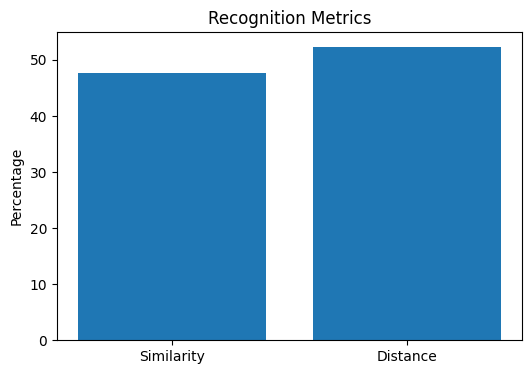

In [ ]:
#Recognition Confidence Bar
import matplotlib.pyplot as plt

labels = ["Similarity", "Distance"]

values = [similarity, best_score*100]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.title("Recognition Metrics")

plt.ylabel("Percentage")

plt.show()

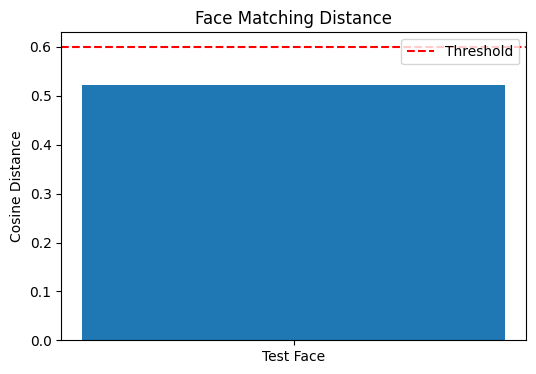

In [ ]:
#Distance Comparison With Threshold
plt.figure(figsize=(6,4))

plt.axhline(y=THRESHOLD,
            color='r',
            linestyle='--',
            label='Threshold')

plt.bar(["Test Face"], [best_score])

plt.ylabel("Cosine Distance")

plt.title("Face Matching Distance")

plt.legend()

plt.show()

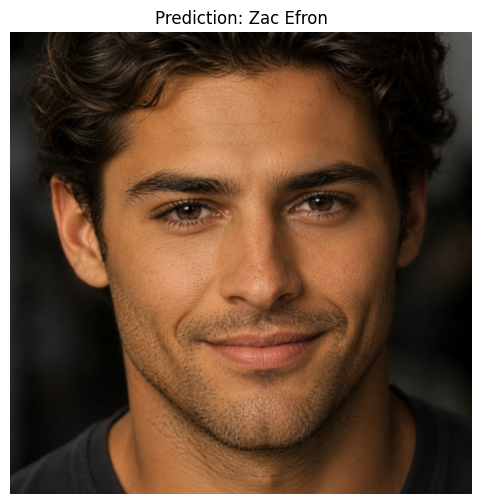

In [ ]:
#Display Input Face With Prediction
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(test_img)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(f"Prediction: {best_match}")

plt.axis("off")

plt.show()

In [ ]:
#Top Match Scores Visualization
scores = {}

for person, embs in database.items():

    min_dist = 999

    for db_emb in embs:

        distance = cosine(test_vector, db_emb)

        if distance < min_dist:

            min_dist = distance

    scores[person] = min_dist

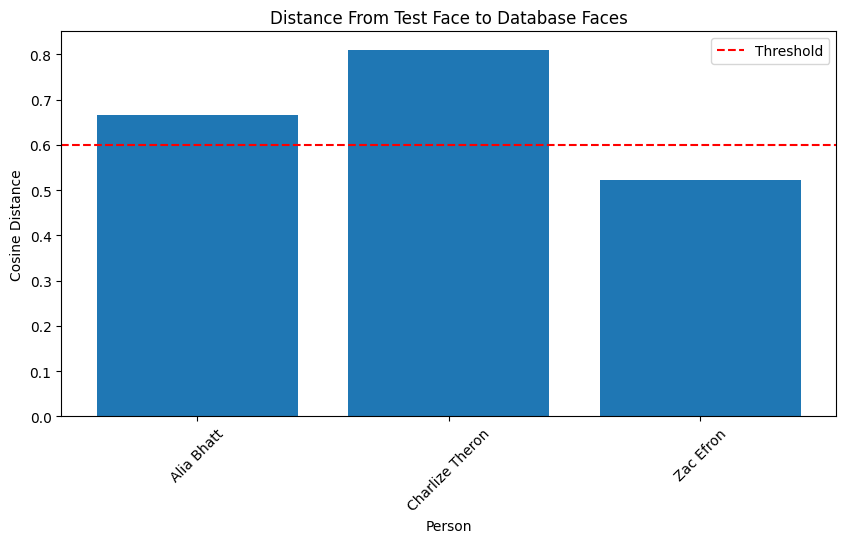

In [ ]:
names = list(scores.keys())

distances = list(scores.values())

plt.figure(figsize=(10,5))

plt.bar(names, distances)

plt.axhline(y=THRESHOLD,
            color='red',
            linestyle='--',
            label='Threshold')

plt.ylabel("Cosine Distance")

plt.xlabel("Person")

plt.title("Distance From Test Face to Database Faces")

plt.xticks(rotation=45)

plt.legend()

plt.show()

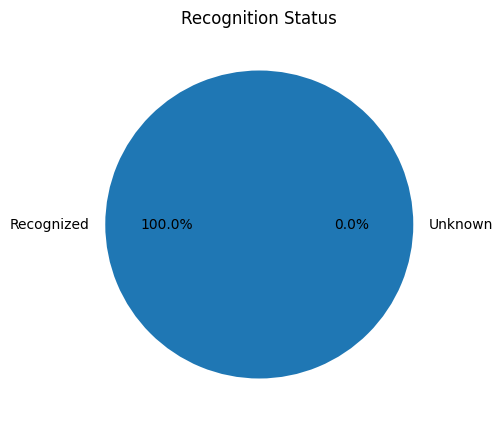

In [ ]:
#Pie Chart for Recognition Result
if best_match == "Unknown":

    sizes = [0, 1]

else:

    sizes = [1, 0]

labels = ["Recognized", "Unknown"]

plt.figure(figsize=(5,5))

plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%')

plt.title("Recognition Status")

plt.show()

In [ ]:
#Final Project-Level Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print(f"Overall Accuracy: {accuracy*100:.2f}%")

Overall Accuracy: 33.33%
